# Plotting recommendations for Chem 4410 - Part 1

I have presented some examples of data plots with linear and non-linear regression data analysis in previous classes and will present many more as we proceed. Over the years my methodology has evolved as I learn more about the tools available. You will see many approaches used to reach the exact same conclusions. This document supports a series of *Python* notebooks that present my current methods. Feel free to steal all this work and use it for yourself. All I ask is that you give credit when appropriate.

the code below will load in tools and set some global variables that will be used in all the code blocks below.

In [1]:
# Setup packages and settings

import numpy as np              # numpy 
import pandas as pd
import matplotlib.pyplot as plt

plt.rcdefaults()
plt.rcParams["figure.figsize"] = (4, 3.5)    # set some default style paramers for plots
#plt.rcParams["figure.dpi"] = 150

print("Setup complete")


Setup complete


## A Simple Plot

Imagine perfroming a simple kinetics plot of a first-order reaction such as $A\longrightarrow B$. The code below will create random data for such a plot. This data will be used in the subsequent plots and data analysis. Fool around with the numbers and have fun.

The integrated rate equation for a first order reaction is...

$$A_t - A_\infty = \left(A_0 - A_\infty \right)e^{-kt} $$

Usually we set up the experiment so that $A_infty$ is zero. We can make this true by waiting a long time until the experiment is surely finished and substracting this final value from the data set. The equation that we will use for such an experiment is...

$$A_t  = A_0 e^{-kt} $$


### Fake the Data

The code will create a data set of absorbance vs time and save that data to a file. Once we have the data, we can just keep using it over and over again. You can change the standard error and the random number seed to get different data sets. You can model different reactions by changing the initial absorbance and the rate constant.

In [2]:
# Generate random Data for first-order chemical kinetics

# -------------------------
# True reaction parameters
# -------------------------
A0 = 0.80       # Initial absorbance at 254nm
k = 0.150       # First-order rate constant (min^-1)

# -------------------------
# Generate time points
# -------------------------
time = np.linspace(1, 40, 40)  # 15 measurements from 0 to 20 min

# -------------------------
# Calculate true values
# -------------------------
A_true = A0 * np.exp(-k * time) # calc

# -------------------------
# Add experimental error
# -------------------------
np.random.seed(12345)          # For reproducibility - will always get the same series of "random" from a given seed

sigma = 0.03                   # Standard deviation of measurement error (Abs)

A_obs = A_true + np.random.normal(
    loc=0,
    scale=sigma,
    size=len(A_true)
)

# -------------------------
# Print data table
# -------------------------
if False:                     # set to True to print out data, False to skip
    print(" Time (min)   Abs A observed (254nm)")
    for t, a in zip(time, A_obs):
        print(f"{t:10.2f}   {a:12.4f}")

# -------------------------
# Create DataFrame
# -------------------------
df = pd.DataFrame({
    "Time_min": time,
    "Abs_obs": A_obs
})

# -------------------------
# Write to CSV
# -------------------------
filename = "first_order_kinetics.csv"
df.to_csv(filename, 
          index=False,
          float_format="%.3f")

print(f"\n Data written to {filename}")    # 




 Data written to first_order_kinetics.csv


### Load the Data

The code below will import the text from the csv file and create a new dataframe containing the data. We can start here so we use the same data again and again. We can reuse the code above if you want new data. perhaps you want to change the standard deviation of the random error.

You can also use this code to read in a csv file of your own data. 

In [3]:
df = pd.read_csv(filename)   # read in the file and convert it to a DataFrame using pandas read_csv tool
print(df.head())             # print just the first few lines

   Time_min  Abs_obs
0       1.0    0.682
1       2.0    0.607
2       3.0    0.495
3       4.0    0.422
4       5.0    0.437


### Plot the Data

The code below will make a simple plot of the $x,y$ data from the DataFrame created above. The code below will take a set of $x,y$ daya and make a plot. You can inspect the code and see the commands for adding a title and other labels. Note the code for writing the plot out as a pdf file.

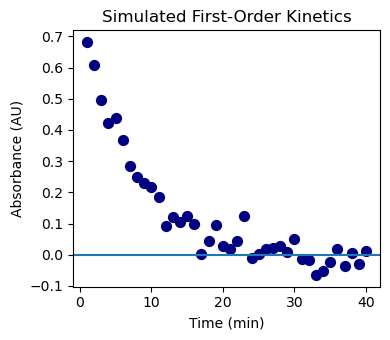

In [4]:
# Plot the raw data

# -------------------------
# get the x and y data
# -------------------------
x = df["Time_min"]
y = df["Abs_obs"]

# -------------------------
# Plot
# -------------------------
plotname = "plot1.pdf"                        # name of file for plot output. Adding ".pdf" will create pdf file.

plt.scatter(                                  # the scatter function will make a classic scatter plot
            x, y,                             # a set of x,y data to plot
            color="navy",                     # many options are available. here I set the color
            s=50,                             # size of the data points. 
            label="Experimental data",        # name of the data set (will be used in a legend)
            )                                 # there are many more option available

plt.axhline(0)                                # Add a line at y=0 (to make a point about data analysis later)

# -------------------------
# Styling the Plot
# -------------------------
plt.xlabel("Time (min)")                      # label the axes
plt.ylabel("Absorbance (AU)")



plt.title("Simulated First-Order Kinetics")   # add a title to the plot
#plt.legend()                                 # display a legend on plot
plt.tight_layout()                            # ensures that the x and y labels are not cut off by the edges

# -------------------------
# Output the Plot
# -------------------------
plt.savefig(plotname)                         # write the plot as an image
plt.show()                                    # show the plot

### Examine Data

It is a very important initial step to plot the raw data. Does it make sense? Here we see a good example of exponential decay. There may be a problem toward the end of the time span where. negative values are being observed due to experimental error. The linearization of the integrated first-order rate equation requires that the exponential function, $\ln$, be applied to the dependant variable (the $y$ data). We cannot apply that function to negative values.

The most important information is within the first few half-lives. The equation is defined as decaying to zero, so we don't really need the noisy data on either side of zero that we get towards the end of the time frame.

Now that we have visualized the raw data we can make some decisions on how to proceed.

## Data Analysis

We want to obtain a value for the rate constant. First, we will need to "clean" the data. That means removing any nonsense. We know that we cannot use the negative values in the linear version of the plot. How shall we go about addressing this issue?

Examine the options below and decide how you want to procede. No matter how badly we screw up, we will have recorded every step in *Python* code for others to check. Any errors can be found and corrected.

### Cleaning the Data

We cannot use the negative numbers for absorbance in the linear form of the integrated rate equation. How shall we address this?

#### Method 1: The Crazy Cut

We can remove the negative values and keep the positive ones. By doing this we are picking and choosing data, which is not a sound statistical approach. We will skew the data toward the positive side of the random error.

The code below will create a data set using only the positive values. I will plot the original, complete data first and then plot the selected, positive data on top so you can compare the new with the old.

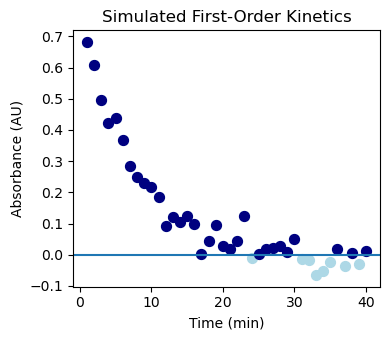

In [5]:
# Plot edited data

# -------------------------
# get the x and y data
# -------------------------
x = df["Time_min"]
y = df["Abs_obs"]


### NEW CODE    This whole code block was just copied from the above and a few new commands added
# -------------------------
# New dataframe with only positive y values
# -------------------------
df_positive = df[df["Abs_obs"] > 0]

# -------------------------
# get the edited x and y data
# -------------------------
x_pos = df_positive["Time_min"]
y_pos = df_positive["Abs_obs"]
### END NEW CODE


# -------------------------
# Plot
# -------------------------
plotname = "plot2.pdf"                        # name of file for plot output. Adding ".pdf" will create pdf file.

plt.scatter(                                  # the scatter function will make a classic scatter plot
            x, y,                             # a set of x,y data to plot
            color="lightblue",                     # many options are available. here I set the color
            s=50,                             # size of the data points. 
            label="Complete data",            # name of the data set (will be used in a legend)
            )                                 # there are many more option available


### NEW CODE    This whole code block was just copied from the above and a few new commands added
plt.scatter(                                  # the scatter function will make a classic scatter plot
            x_pos, y_pos,                     # a set of edited data to plot
            color="navy",                     # many options are available. here I set the color
            s=50,                             # size of the data points. 
            label="Edited data",              # name of the data set (will be used in a legend)
            )                                 # there are many more option available
### END NEW CODE


plt.axhline(0)                                # Add a line at y=0 (to make a point about data analysis later)

# -------------------------
# Styling the Plot
# -------------------------
plt.xlabel("Time (min)")                      # label the axes
plt.ylabel("Absorbance (AU)")
plt.title("Simulated First-Order Kinetics")   # add a title to the plot
#plt.legend()                                 # display a legend on plot
plt.tight_layout()                            # ensures that the x and y labels are not cut off by the edges

# -------------------------
# Output the Plot
# -------------------------
plt.savefig(plotname)                         # write the plot as an image
plt.show()                                    # show the plot



The data set above does favour the higher values in the tail end of the data set. I believe that it will skew toward a slightly higher value for the rate constant. We cannot justify delting the negative points for a statistical reason. Why not delete the positive points? Why not delete both positive and negative where in the problem region? Hmmm. We might be on to something.

#### Method 2: the Big Short

I can eyeball the half-life the the reaction to be 5 minutes or less. So three half-lives would be 15 seconds. That should get us to almost 90% of the reactant being consumed. That's probably more than enough data to get a decent estimate of the rate constant. 

The code below will select all rows of the dataframe at and before 15 minutes. Again, I will plot the old data under the edited data for comparison.

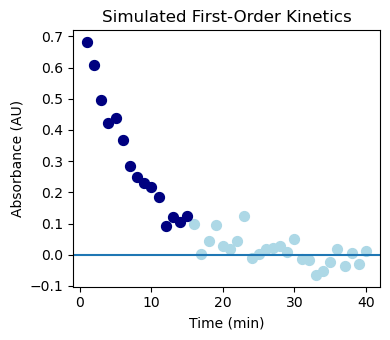

In [6]:
# Plot edited data

# -------------------------
# get the x and y data
# -------------------------
x = df["Time_min"]
y = df["Abs_obs"]


### NEW CODE    This whole code block was just copied from the above and a few new commands added
# -------------------------
# New dataframe with time values at or less than 15 minutes
# -------------------------
df_cut = df[df["Time_min"] <= 15]

# -------------------------
# get the edited x and y data
# -------------------------
x_cut = df_cut["Time_min"]
y_cut = df_cut["Abs_obs"]
### END NEW CODE


# -------------------------
# Plot
# -------------------------
plotname = "plot3.pdf"                        # name of file for plot output. Adding ".pdf" will create pdf file.

plt.scatter(                                  # the scatter function will make a classic scatter plot
            x, y,                             # a set of x,y data to plot
            color="lightblue",                     # many options are available. here I set the color
            s=50,                             # size of the data points. 
            label="Complete data",            # name of the data set (will be used in a legend)
            )                                 # there are many more option available


### NEW CODE    In here I only changed the names of the x and y points. Reuse! Cut and Paste!
plt.scatter(                                  # the scatter function will make a classic scatter plot
            x_cut, y_cut,                     # a set of edited data to plot
            color="navy",                     # many options are available. here I set the color
            s=50,                             # size of the data points. 
            label="Edited data",              # name of the data set (will be used in a legend)
            )                                 # there are many more option available
### END NEW CODE


plt.axhline(0)                                # Add a line at y=0 (to make a point about data analysis later)

# -------------------------
# Styling the Plot
# -------------------------
plt.xlabel("Time (min)")                      # label the axes
plt.ylabel("Absorbance (AU)")
plt.title("Simulated First-Order Kinetics")   # add a title to the plot
#plt.legend()                                 # display a legend on plot
plt.tight_layout()                            # ensures that the x and y labels are not cut off by the edges

# -------------------------
# Output the Plot
# -------------------------
plt.savefig(plotname)                         # write the plot as an image
plt.show()                                    # show the plot



## Linear Regression Analysis

You are coming from the dark world of Microsoft Excel. For the rest of this notebook we will stay within the lowly capabilities of that business tool. We will use straight lines only for data analysis. Business believes everything must be a straight line (preferable going up). In the next notebook I will show you the new shiny world of "the curve" -- a world that will break Excel's "trendline" function. We will be free to analyze any arbitrary system, not just ones shoehorned into a linear form by hook and crook.

### The Linear Integrated Rate Equation

You will likely never use calculus again. Its all been done for the simple case and, when things get complicated, scientists are quick to jump to numerical methods. The integrated first-order rate equation is one of those famous cases where the work has already been done.

We can rearrange the exponential form of the rate equation...

$$A_t  = A_0 e^{-kt} $$

to a linear form...

$$\ln{A_t}  = \ln{A_0} -kt $$

We can now see why we had to 86 the negative values. $\ln{x}$ is only defined for positive values.

### Data Calculations

We will now obtain a set of data in a linear form. First I will need to convert the data to something meaningful in reactions kinetics. We don't care about how fast absorbance changes, we care about the concentration. So we will first convert absorbance to concentration using an imaginary value for the molar absorptivity constant, $\epsilon$. We will say that $\epsilon = 300\ L\,mole^{-1}$

To satisfy the linear form of the integrated first order rate equation we will need to plot $\ln$ of concentration vs time. I will need to apply the $ln$ function to the concentration values.

The code below will add columns to the dataframe with these calculations applied. We will start with the truncated data set (all data points up to 15 minutes).

In [7]:
epsilon = 300               # molar absorptivity in L mole^-1

df_cut["conc_molar"] = df_cut["Abs_obs"] / epsilon
df_cut["ln_conc"] = np.log(df_cut["conc_molar"]) 

df_cut.head()

,Time_min,Abs_obs,conc_molar,ln_conc
0,1.0,0.682,0.002273,-6.086508
1,2.0,0.607,0.002023,-6.203009
2,3.0,0.495,0.001650,-6.406980
3,4.0,0.422,0.001407,-6.566532
4,5.0,0.437,0.001457,-6.531605


We can now plot $ln$ of concentration vs time and the slope will be $-k$.

### Linear Regression using LMFit

*Python* provides many tools for simple linear regression optimizations. In other notebooks throughout this course you will see me use tools such as `scipy.stats.linregress`, `numpy.polyfit`, and `scipy.optimize.curve_fit`. I have seen others use the `statsmodels` package, but I am going to use the `LMFit` package. It is a powerful "all-in-one" optimization and analysis package. Until I find something better, I will be using only LMFit going forward. the `linregress` tool is very simple and can fit a linear model with a single line of code. However, rather than present a simple case and then move on, never returning, I will just start at the destination, `LMFit`.

In the code below I create a *Python* object named `model` by calling the `lmfit.models.LinearModel()` function. I also create a parameter object called `param`. The parameter object can set the variables to be optimize and establish initial values and bounds. In this case we can just create the parameter object automatically by using the `guess()` function built inb to the `model` object.

We then use the `fit()` function within the `model` to optimize the line fit. The function returns an object that contains all the results and statistical information. In the code below, I assign the result object to the name `result`.

The `result` object has many tools built into it. You can see the `fit_report()` function being used to generate a detailed statistical report and the `ci_report()` function used to create a set of confidence intervals for the parameters. The `plot()` function creates a plot without any need to use MatPlotLib functions directly, although I did use some to add labels to the plot and save the plot as a pdf file.

In a nutshell, I created a model, created parameters to be optimized using that model, and then optimized the parameters using the model and a set of $x,y$ data. This produced a result that contains a lot of information.


[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 4
    # data points      = 15
    # variables        = 2
    chi-square         = 0.32735656
    reduced chi-square = 0.02518127
    Akaike info crit   = -53.3713326
    Bayesian info crit = -51.9552322
    R-squared          = 0.94403012
[[Variables]]
    slope:     -0.14042591 +/- 0.00948331 (6.75%) (init = -0.1404259)
    intercept: -5.94289682 +/- 0.08622338 (1.45%) (init = -5.942897)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.8799

              99.73%    95.45%    68.27%    _BEST_    68.27%    95.45%    99.73%
 slope    :  -0.03503  -0.02098  -0.00986  -0.14043  +0.00986  +0.02098  +0.03503
 intercept:  -0.31853  -0.19071  -0.08967  -5.94290  +0.08967  +0.19071  +0.31853


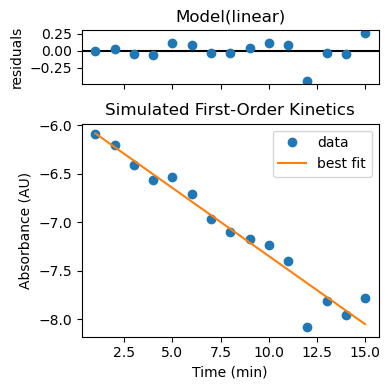

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit 

# Example data
x = df_cut["Time_min"]         # select x and y data
y = df_cut["ln_conc"]

# Create model
model = lmfit.models.LinearModel()    # create an 'object' called 'model' that is a wrapper for the lmfit.models.LinearModel() function

# Create initial parameter estimates
params = model.guess(y, x=x)          # create the parameter list. The `guess` method will handle everything automatically
                                      # with the LinearModel model, the parameters will be 'slope' and 'intercept'
                                      # note: 'guess' is only available for built-in models like 'LinearModel'
# Fit
result = model.fit(y, params, x=x)    # optimize the parameters created above (slope & intercept) to achieve a best fit of calculated y values to real y values for each x value
                                      # the 'result' object contains all the statistical results
# Display results
print(result.fit_report())            # print out the 'fit_report' that is contained in the 'result' object
print()
print(result.ci_report())

# Plot Results
result.plot()

# Style the plot

plt.xlabel("Time (min)")                      # label the axes
plt.ylabel("Absorbance (AU)")
plt.title("Simulated First-Order Kinetics")   # add a title to the plot
#plt.legend()                                 # display a legend on plot
plt.tight_layout()                            # ensures that the x and y labels are not cut off by the edges

plt.savefig("plot4.pdf")
plt.show()

### Interpreting the Fit Report

The fit report above contains many statistical scores, most of which we do not need. We obtained estimates for the best fit parameters values and standard errors. The intercept was estimated to be $b = -5.943 \pm 0.086$ and the slope was estimated to be $k = -0.140 \pm 0.009\ min^{-1}$. We can obtain the value for $A_0$ from the intercept, $b$.

The standard error for a parameter means that if we repeated the experiment a billion times, we would see the optimized values be within the range of the standard error value 66% of the time. this is often called the $1\sigma$ error. If we double the standard error we will capture 95% of likely valued for the parameter. This $2\sigma$ value is what is often reported. In the literature, authors often do not make it clear if they are reporting the standard errors at $1\sigma$ or $2\sigma$. Since we will always do our calculations in a *Python* notebook, anyone can inspect our work and see what we are doing, even if we are vague in our writing.


The $R^2$ value is the square of the Pearson correlation coefficent. It is a useless number and is meaningful only with linear optimizations. We will not be crowing if our line fit gave $R^2 = 0.9999$. The $R^2$ value does indicate that the data aligns with the model, but it does not provide information about the quality of the parameter fits. We can have a high value for $R^2$ and still have poorly fit parameters with large standard errors when the model is inadequate. In the case of a two-parameter line fit, though, I will admit that $R^2$ can be reliable. I never use it because we really should not be linearizing equations in the first place. More about that later.

### The Confidence Interval
The confidence interval report gives values related to standard error but from a more sophisticated Bayesian analysis of the data set. I can't explain it, but I can use it. Anyone can look up exactly how LMFit implements this calculation if they want; it's all open source.

The 66% confidence interval is similar to the standard error. However the two numbers are close but not identical.

The reason is that `LMFit` computes confidence intervals using a more rigorous procedure based on the shape of the $\chi^2$ surface around the optimum. The fit report uncertainty comes from the covariance matrix, whereas the CI report is obtained by actually exploring parameter space.

In the example above, the $2\sigma$ standard error for the intercept is $\pm 0.17$ and the 95% confidence interval ($2\sigma$) is $\pm 0.19$. For linear fits, these values are usually similar and it doesn't really matter which you use.

### Calculations and Error Propagation

The slope and intercept can be extracted from the `result` object as uncertain values (the number includes the standard error). the `Uncertainties` package provides this tool and we can use the math tools to propagate error in calulations using the line fit parameters. When we convert the intercept to a value for $A_0$, we will need to propagate the error though an exponential function. I don't know how to do that, but the tools in the `Uncertainties` package will handle all of that for me. Anyone examining this notebook will be able to see exactly what tools I used so I don't need to explain the method used for error propagation, just that I used the `Uncertainties` package.

### Calculating the Initial Concentration

The estimated intercept is the $\ln$ of the initial concentration value. We can convert it to concentration using an exponential function. We will not use the *NumPy* function, `np.exp()`, but will use the version provided from the `Uncertainties` package, `unp.exp()`, which can handle uncertain floating point values.

The code below will calculate the initial concentration from the intercept with error propagation. First we will extract the parameters and the covariance matrix and then use both of these to generate the correlated uncertain ufloat values for both parameters. Since we are doing a calculation at the intercept we don't have to worry about correlation, but it is best to keep correlation information included within the ufloat objects for any calculations that involve both number. they are highly correlated (correlation between slope and intercept is $-0.88$).

In [ ]:
from uncertainties import unumpy as unp        # pull tools from the Uncertainties package
from uncertainties import correlated_values

parvals = [result.params['slope'].value,        # get the nominal value (no error included) for each parameter
           result.params['intercept'].value]

cov = result.covar                              # get the covariance matrix, which contains information about the standard errors and correlations

slope_u, intercept_u = correlated_values(parvals, cov) # combine values and the covariance matrix to generate correlated ufloat objects for the parameters
conc_0 = unp.exp(intercept_u)                   # use the exponential function from the Uncertainties package to perform calculations on u_floats with correct error propagation

print(f"The rate constant is {-slope_u:0.4f} min^-1 (1 sigma)") # I am using f-strings to print the numbers withing a text string. Google it or ask CoPilot.
print(f"The initial conc is {conc_0:0.5f} moles/L (1 sigma)")
print()
print(f"The rate constant used to generate the data is exactly {k:0.3f} min^-1")
print(f"The initial conc used to generate the data is exactly {A0/epsilon:0.5f} moles/L")


The rate constant is 0.1404+/-0.0095 min^-1 (1 sigma)
The initial conc is 0.00262+/-0.00023 moles/L (1 sigma)

The rate constant used to generate the data is exactly 0.150 min^-1
The initial conc used to generate the data is exactly 0.00267 moles/L


The exact initial values used to generate the data were... 

\begin{align*}
k &= 0.15\,\text{min}^{-1} \\
A_0 &= 2.67\,\text{mM}
\end{align*}

Note that I converted the initial absorbance to concentration here.

The estimated parameters are reported at $2\sigma$ (95%) confidence to be...

\begin{align*}
k &= 0.140 \pm 0.019\,\text{min}^{-1} \\
A_0 &= 2.62 \pm 0.23\,\text{mM}
\end{align*}

Our line fit estimates include the true values within the 95% confidence interval ($2\sigma$). The error propagation in converting the intercept to concentration were handle through an exponential function without any effort on my part. I just called the appropriate *Python* tool.

### Interpreting the Plot

The `plot()` function in the `result` object generated a plot that included two components. The lower plot is a plot of the data and the best fit line. We can see that the data and the line match well. 

A better way to visualize the quality of the fit is to plot the difference between the calculated $y$-values using the best-fit parameters and the actual data. This difference between the best-fit line and the data is the residuals of the plot. The upper plot generated by the `plot()` function is a plot of the residuals. We can see that the residuals are randomly located on either side of zero. this indicates a good fit. If we observed a systematic deviation, for example as curved residual plot, we would know that the model was incorrect or incomplete.

Always visualize the plot with the best-fit line and the residual plot. Your eyes can evaluate the quality of a fit better than a set of numbers.